In [2]:
#Instalamos las librerías necesarias para reglas de asociación y visualización
!pip install mlxtend squarify --quiet

#IMPORTANTE: Una vez terminada la instalación, vaya a:
#'Entorno de ejecución' -> 'Reiniciar sesión' para aplicar los cambios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import squarify
import warnings

#Herramientas de Machine Learning para Reglas de Asociación
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings('ignore')
%matplotlib inline

print(f"Librerías cargadas con éxito.")
print(f"Numpy version: {np.__version__}")

Librerías cargadas con éxito.
Numpy version: 2.0.2


In [10]:
#Carga del dataset (Asegúrese de subir Market_Basket_Optimisation.csv a Colab)
try:
  df_raw = pd.read_csv('Market_Basket_Optimisation.csv', header=None)


  transacciones = []
  for i in range(df_raw.shape[0]):
      #Convertimos cada fila en una lista, eliminando valores 'nan'
      #El TransactionEncoder requiere una lista de listas de strings.
      fila = [str(df_raw.values[i,j]) for j in \
range(df_raw.shape[1]) if str(df_raw.values[i,j]) != 'nan']
      transacciones.append(fila)

  print(f"Procesadas {len(transacciones)} transacciones con éxito.")
except FileNotFoundError:
    print("Error: Por favor suba el archivo CSV al panel izquierdo de Colab.")
df.head(5)

Procesadas 7501 transacciones con éxito.


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


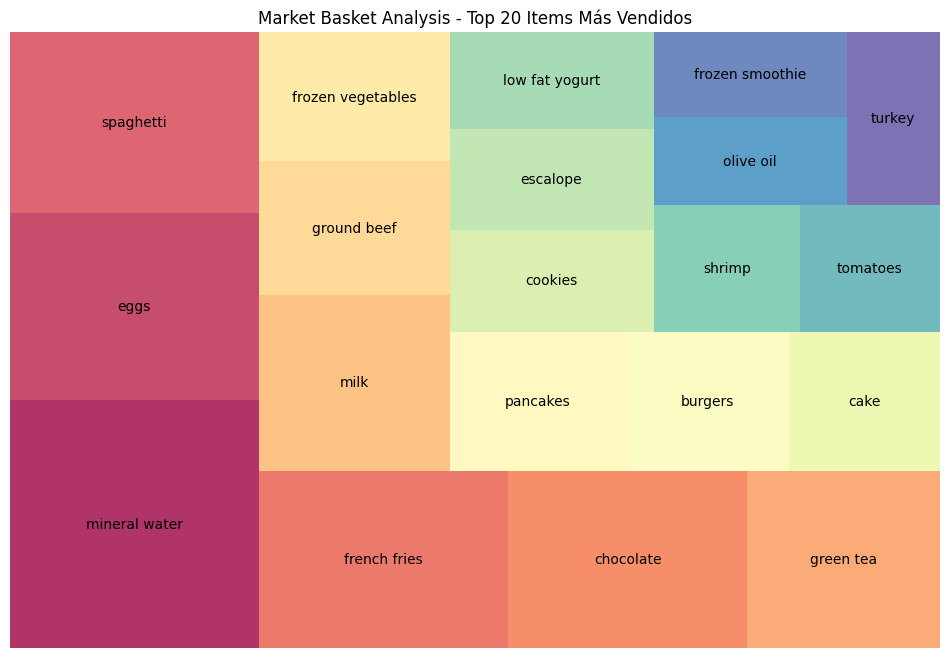

In [4]:
#Contamos frecuencias aplanando el dataset original
df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
df_counts = df.stack().value_counts()
df_res = df_counts.to_frame(name='Frecuencia').reset_index()
df_res.columns = ['Producto', 'Frecuencia']

#Visualización del Top 20 Items
plt.figure(figsize=(12, 8))
top_20 = df_res.head(20)
squarify.plot(sizes=top_20['Frecuencia'], label=top_20['Producto'],
alpha=0.8, color=plt.cm.Spectral(np.linspace(0, 1, 20)))
plt.title('Market Basket Analysis - Top 20 Items Más Vendidos')
plt.axis('off')
plt.show()

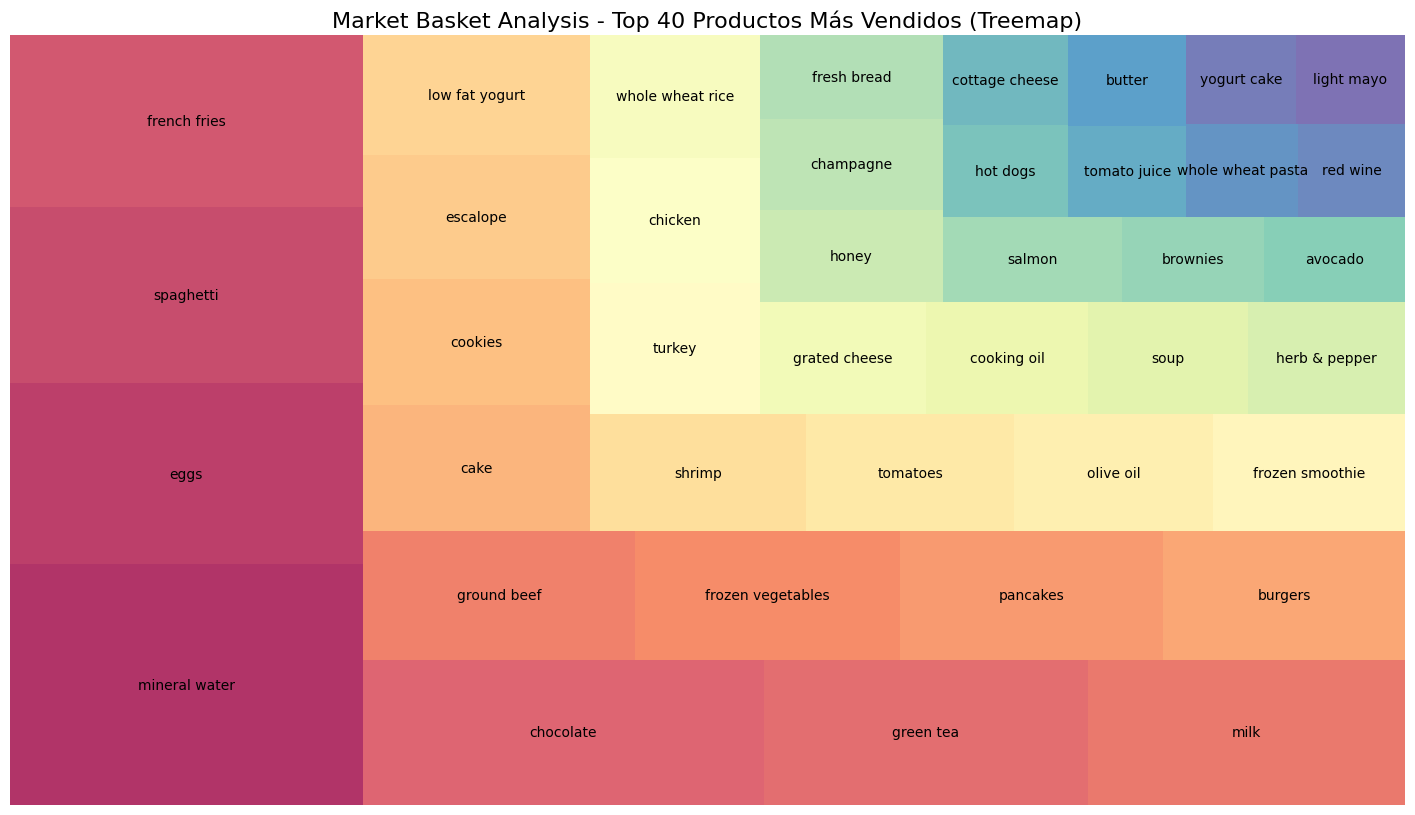

In [14]:
import matplotlib.pyplot as plt
import squarify # Asegúrate de que esta librería ya esté instalada

# Obtener los top 40 productos del DataFrame df_res
top_40_productos = df_res.head(40)

# Preparar los datos para squarify
sizes = top_40_productos['Frecuencia']
labels = top_40_productos['Producto']

# Crear el treemap
plt.figure(figsize=(18, 10)) # Aumentar el tamaño para acomodar más elementos
squarify.plot(sizes=sizes, label=labels, alpha=0.8,
              color=plt.cm.Spectral(np.linspace(0, 1, len(top_40_productos)))) # Usar un colormap para variar los colores

plt.title('Market Basket Analysis - Top 40 Productos Más Vendidos (Treemap)', fontsize=16)
plt.axis('off') # Ocultar los ejes
plt.show()

In [11]:
print("Los 10 productos más frecuentes son:")
print(df_res.head(10))

Los 10 productos más frecuentes son:
            Producto  Frecuencia
0      mineral water        1788
1               eggs        1348
2          spaghetti        1306
3       french fries        1282
4          chocolate        1230
5          green tea         991
6               milk         972
7        ground beef         737
8  frozen vegetables         715
9           pancakes         713


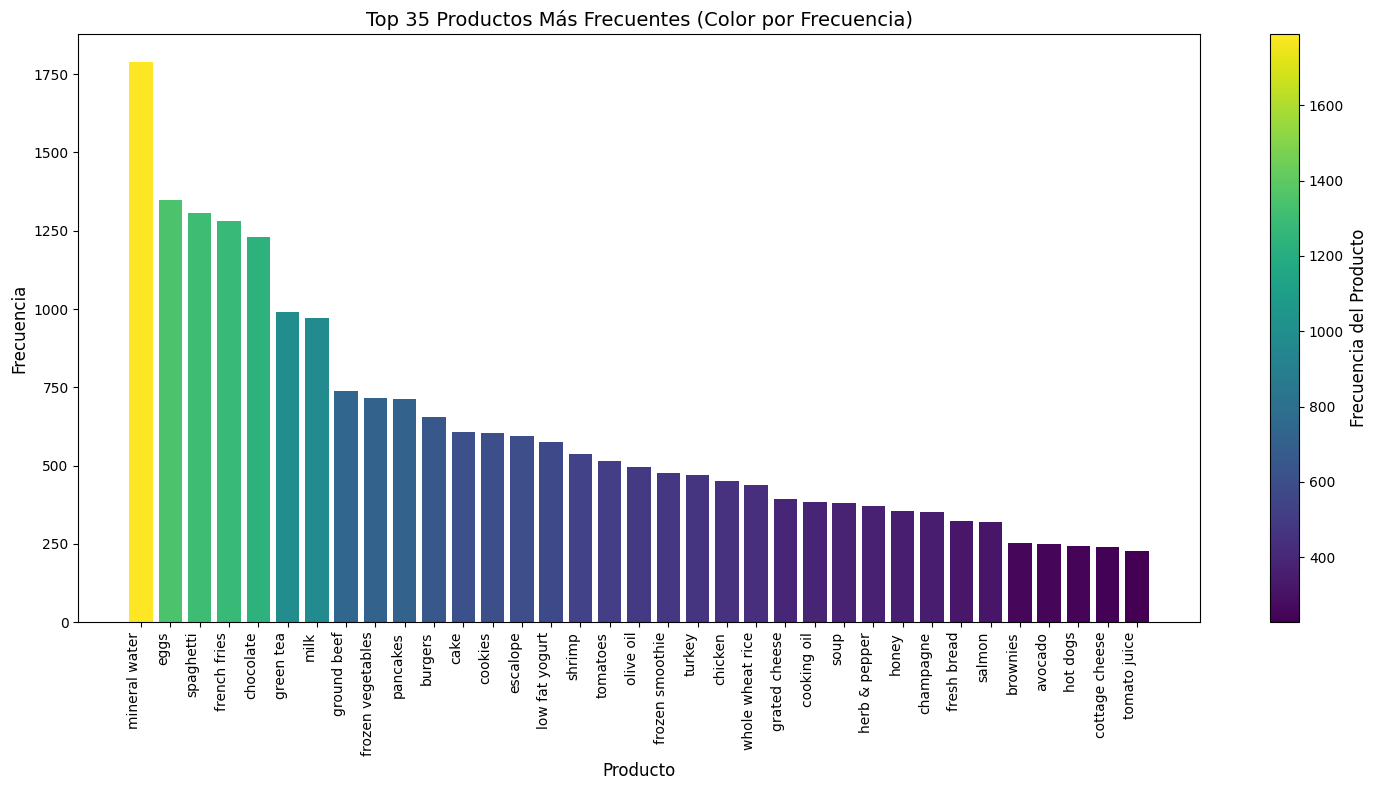

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# Obtener los top 35 productos del DataFrame df_res
top_35_productos = df_res.head(35)

# Crear un normalizador de color basado en la frecuencia
norm = colors.Normalize(vmin=top_35_productos['Frecuencia'].min(), vmax=top_35_productos['Frecuencia'].max())
cmap = cm.viridis # Puedes cambiar el colormap a tu gusto, por ejemplo 'YlOrRd', 'plasma', 'magma'

plt.figure(figsize=(15, 8))
# Asignar color a cada barra usando el colormap
plt.bar(top_35_productos['Producto'], top_35_productos['Frecuencia'],
        color=cmap(norm(top_35_productos['Frecuencia'])))

plt.xlabel('Producto', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Top 35 Productos Más Frecuentes (Color por Frecuencia)', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=10) # Rotar las etiquetas para mejor legibilidad
plt.yticks(fontsize=10)
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten

# Añadir una barra de color (colorbar) para indicar la escala de frecuencia
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) # Necesario para que el colorbar funcione correctamente
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Frecuencia del Producto', fontsize=12)

plt.show()

In [15]:
#Transformamos la lista de transacciones a una matriz binaria
te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dimensiones de la matriz codificada: {df_encoded.shape}")
#Ahora tenemos una columna por cada producto único en el dataset.

Dimensiones de la matriz codificada: (7501, 120)


In [16]:
#Encontramos itemsets frecuentes con un soporte mínimo (ej. 1%)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

#Generamos reglas de asociación basadas en la métrica Lift
#Filtramos reglas con un Lift mayor a 1 para asegurar asociaciones no aleatorias.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

#Ordenamos por Lift descendente para ver las reglas más fuertes primero
rules = rules.sort_values('lift', ascending=False)

#Mostramos las 10 reglas con mayor fuerza de asociación
print("Top 10 Reglas de Asociación:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Top 10 Reglas de Asociación:
                    antecedents                 consequents   support  \
215             (herb & pepper)               (ground beef)  0.015998   
214               (ground beef)             (herb & pepper)  0.015998   
385               (ground beef)  (spaghetti, mineral water)  0.017064   
384  (spaghetti, mineral water)               (ground beef)  0.017064   
397                 (olive oil)  (spaghetti, mineral water)  0.010265   
396  (spaghetti, mineral water)                 (olive oil)  0.010265   
193                  (tomatoes)         (frozen vegetables)  0.016131   
192         (frozen vegetables)                  (tomatoes)  0.016131   
189                    (shrimp)         (frozen vegetables)  0.016664   
188         (frozen vegetables)                    (shrimp)  0.016664   

     confidence      lift  
215    0.323450  3.291994  
214    0.162822  3.291994  
385    0.173677  2.907928  
384    0.285714  2.907928  
397    0.155870  2.609786  